--- Loading Dataset ---
OLS Linear Regression -> MSE: 0.000675, R2: 0.0016
Ridge Regression     -> MSE: 0.000675, R2: 0.0016

Logistic Regression (C=1.0) Metrics:
  Accuracy:  0.4966
  Precision: 0.5068
  Recall:    0.4934
  F1-Score:  0.5000



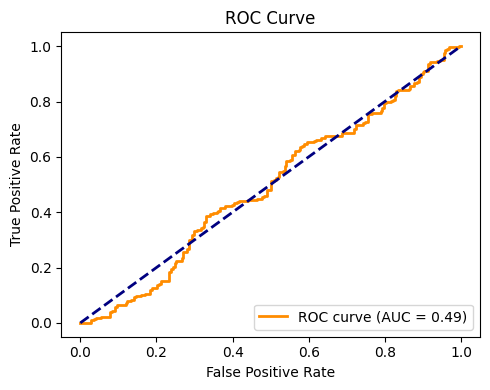

Threshold Sensitivity Table:
  Thresh: 0.3 | Precision: 0.510 | Recall: 1.000 | F1: 0.676
  Thresh: 0.4 | Precision: 0.517 | Recall: 0.991 | F1: 0.680
  Thresh: 0.5 | Precision: 0.507 | Recall: 0.493 | F1: 0.500
  Thresh: 0.6 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
  Thresh: 0.7 | Precision: 0.000 | Recall: 0.000 | F1: 0.000

--- Training Regularized Logistic Regression (C=0.01) ---

95% Bootstrap Confidence Interval for AUC Difference:
  Lower Bound: -0.027130
  Upper Bound: 0.002149


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# 1. Load Clean Dataset
print("--- Loading Dataset ---")
df = pd.read_csv('cleaned_data.csv')

# Separate features from target columns
X = df.drop(columns=['Daily_Return', 'Instrument_ID'])
y_reg = df['Daily_Return']

# Create classification binary label: 1 if daily return is above its median, else 0
median_return = y_reg.median()
y_clf = (y_reg > median_return).astype(int)

# 2. One-Hot Encode Categorical Columns
X = pd.get_dummies(X, columns=['Asset_Class'], drop_first=True)

# 3. Train-Test Split (80/20 split)
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# 4. Standard Scaling (Fitted only on training data to prevent leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Regression Models (OLS Linear & Ridge)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)
y_reg_pred_lr = lr_model.predict(X_test_scaled)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_reg_train)
y_reg_pred_ridge = ridge_model.predict(X_test_scaled)

print(f"OLS Linear Regression -> MSE: {mean_squared_error(y_reg_test, y_reg_pred_lr):.6f}, R2: {r2_score(y_reg_test, y_reg_pred_lr):.4f}")
print(f"Ridge Regression     -> MSE: {mean_squared_error(y_reg_test, y_reg_pred_ridge):.6f}, R2: {r2_score(y_reg_test, y_reg_pred_ridge):.4f}\n")

# 6. Classification Model (Logistic Regression C=1.0)
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_scaled, y_clf_train)
y_clf_pred = clf_model.predict(X_test_scaled)
y_clf_proba = clf_model.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic Regression (C=1.0) Metrics:")
print(f"  Accuracy:  {accuracy_score(y_clf_test, y_clf_pred):.4f}")
print(f"  Precision: {precision_score(y_clf_test, y_clf_pred):.4f}")
print(f"  Recall:    {recall_score(y_clf_test, y_clf_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_clf_test, y_clf_pred):.4f}\n")

# Plot and save ROC Curve
fpr, tpr, _ = roc_curve(y_clf_test, y_clf_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

# 7. Decision-threshold sensitivity check
print("Threshold Sensitivity Table:")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_thresh = (y_clf_proba >= t).astype(int)
    print(f"  Thresh: {t} | Precision: {precision_score(y_clf_test, y_thresh, zero_division=0):.3f} | Recall: {recall_score(y_clf_test, y_thresh, zero_division=0):.3f} | F1: {f1_score(y_clf_test, y_thresh, zero_division=0):.3f}")

# 8. Regularization Experiment (C=0.01)
print("\n--- Training Regularized Logistic Regression (C=0.01) ---")
clf_reg_model = LogisticRegression(C=0.01, max_iter=1000)
clf_reg_model.fit(X_train_scaled, y_clf_train)
y_clf_reg_proba = clf_reg_model.predict_proba(X_test_scaled)[:, 1]

# 9. Bootstrap Confidence Interval for AUC Difference (500 iterations)
n_iterations = 500
auc_diffs = []
y_clf_test_series = pd.Series(y_clf_test).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(X_test_scaled)

np.random.seed(42)
for _ in range(n_iterations):
    indices = np.random.choice(len(y_clf_test_series), size=len(y_clf_test_series), replace=True)
    y_boot = y_clf_test_series.iloc[indices]
    if len(np.unique(y_boot)) < 2: continue
    X_boot = X_test_scaled_df.iloc[indices]

    auc_1 = auc(roc_curve(y_boot, clf_model.predict_proba(X_boot)[:, 1])[0], roc_curve(y_boot, clf_model.predict_proba(X_boot)[:, 1])[1])
    auc_01 = auc(roc_curve(y_boot, clf_reg_model.predict_proba(X_boot)[:, 1])[0], roc_curve(y_boot, clf_reg_model.predict_proba(X_boot)[:, 1])[1])
    auc_diffs.append(auc_1 - auc_01)

print(f"\n95% Bootstrap Confidence Interval for AUC Difference:")
print(f"  Lower Bound: {np.percentile(auc_diffs, 2.5):.6f}")
print(f"  Upper Bound: {np.percentile(auc_diffs, 97.5):.6f}")